<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 148.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 157.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 168.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 128.5 MB/s eta 0:00:00


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [4]:
print(df.shape)
print(df.dtypes)
print(df.info())

(65437, 114)
ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [5]:
cols_criticas = ['Employment', 'JobSat', 'RemoteWork']
print("Antes:")
print(df[cols_criticas].isnull().sum())

for col in cols_criticas:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

print("\nDepois:")
print(df[cols_criticas].isnull().sum())

Antes:
Employment        0
JobSat        36311
RemoteWork    10631
dtype: int64

Depois:
Employment    0
JobSat        0
RemoteWork    0
dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [6]:
print("=== Employment ===")
print(df['Employment'].value_counts().head(10))

print("\n=== JobSat ===")
print(df['JobSat'].value_counts())

print("\n=== YearsCodePro ===")
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
print(df['YearsCodePro'].describe())

=== Employment ===
Employment
Employed, full-time                                                         39041
Independent contractor, freelancer, or self-employed                         4846
Student, full-time                                                           4709
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Employed, part-time                                                          1266
Student, full-time;Employed, part-time                                       1115
Employed, full-time;Student, full-time                                        897
Employed, full-time;Student, part-time                                        839
Student, full-time;Not employed, but looking for work                         686
Name: count, dtype: int64

=== JobSat ===
JobSat
8.0     43820
7.0      6379
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0      1165
4.0

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


In [8]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 197.2 MB/s eta 0:00:00


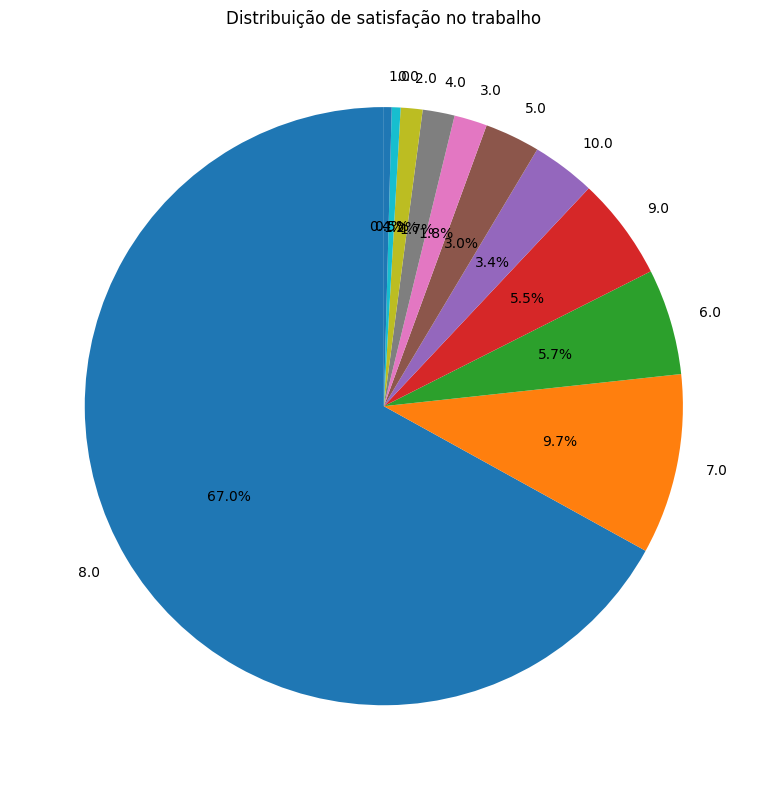

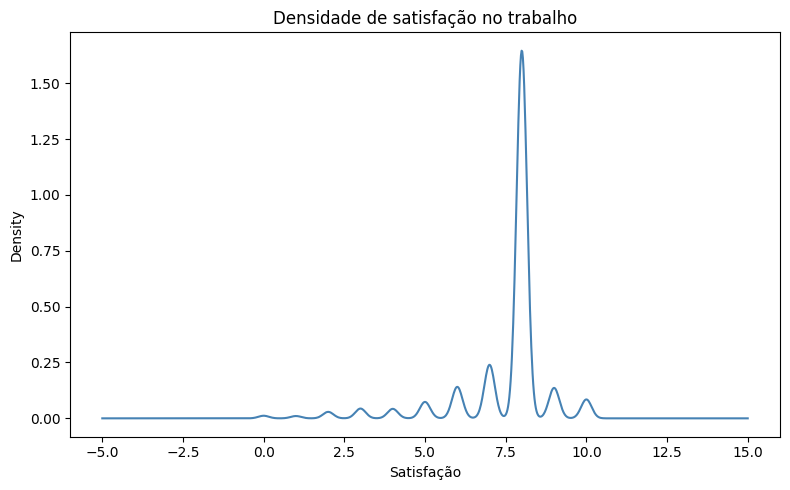

In [9]:
# Gráfico de pizza
plt.figure(figsize=(8, 8))
df['JobSat'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribuição de satisfação no trabalho')
plt.ylabel('')
plt.tight_layout()
plt.show()

# KDE plot
plt.figure(figsize=(8, 5))
df['JobSat'].dropna().astype(float).plot(kind='kde', color='steelblue')
plt.title('Densidade de satisfação no trabalho')
plt.xlabel('Satisfação')
plt.tight_layout()
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


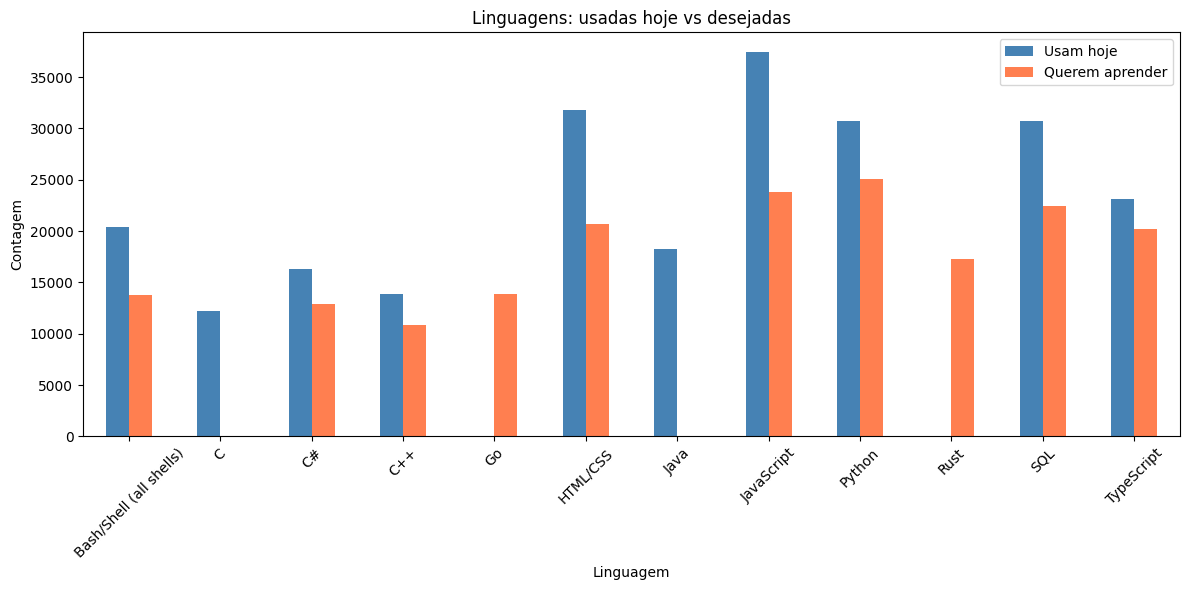

In [10]:
# Separar linguagens de cada coluna
lang_have = df['LanguageHaveWorkedWith'].str.split(';').explode().str.strip().value_counts().head(10)
lang_want = df['LanguageWantToWorkWith'].str.split(';').explode().str.strip().value_counts().head(10)

# Unir em um DataFrame para comparar
lang_df = pd.DataFrame({'Usam hoje': lang_have, 'Querem aprender': lang_want}).fillna(0)

lang_df.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'coral'])
plt.title('Linguagens: usadas hoje vs desejadas')
plt.xlabel('Linguagem')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


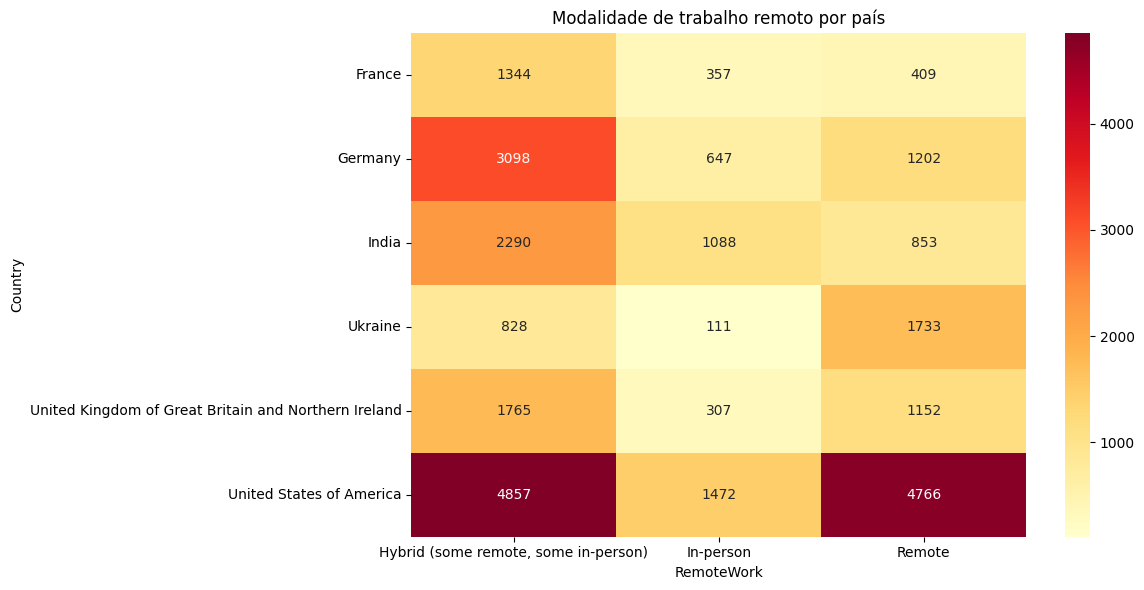

In [11]:
top_paises = df['Country'].value_counts().head(6).index
df_top = df[df['Country'].isin(top_paises)]

crosstab = pd.crosstab(df_top['Country'], df_top['RemoteWork'])

plt.figure(figsize=(12, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Modalidade de trabalho remoto por país')
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


Correlação de Pearson: 0.076 (p-value: 0.0000)
Correlação de Spearman: 0.079 (p-value: 0.0000)


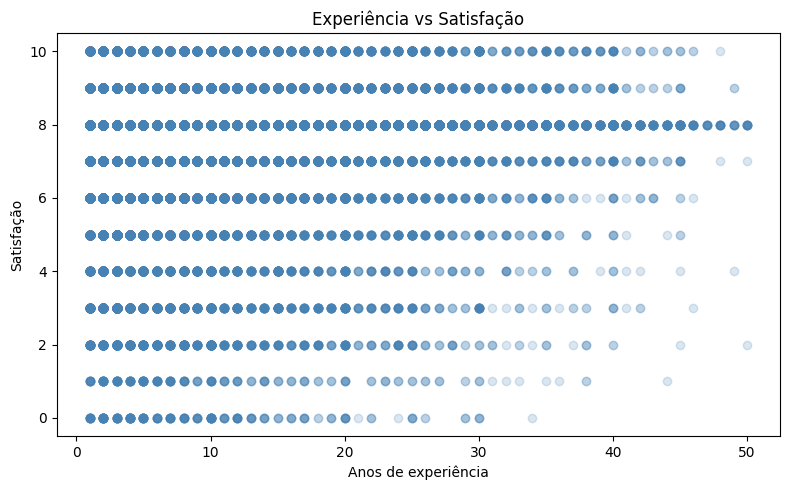

In [12]:
from scipy import stats

df['JobSat_num'] = pd.to_numeric(df['JobSat'], errors='coerce')
df_corr = df[['YearsCodePro', 'JobSat_num']].dropna()

# Pearson — para dados numéricos contínuos
pearson_r, pearson_p = stats.pearsonr(df_corr['YearsCodePro'], df_corr['JobSat_num'])
print(f"Correlação de Pearson: {pearson_r:.3f} (p-value: {pearson_p:.4f})")

# Spearman — mais robusto para dados com outliers
spearman_r, spearman_p = stats.spearmanr(df_corr['YearsCodePro'], df_corr['JobSat_num'])
print(f"Correlação de Spearman: {spearman_r:.3f} (p-value: {spearman_p:.4f})")

plt.figure(figsize=(8, 5))
plt.scatter(df_corr['YearsCodePro'], df_corr['JobSat_num'], alpha=0.2, color='steelblue')
plt.title('Experiência vs Satisfação')
plt.xlabel('Anos de experiência')
plt.ylabel('Satisfação')
plt.tight_layout()
plt.show()

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


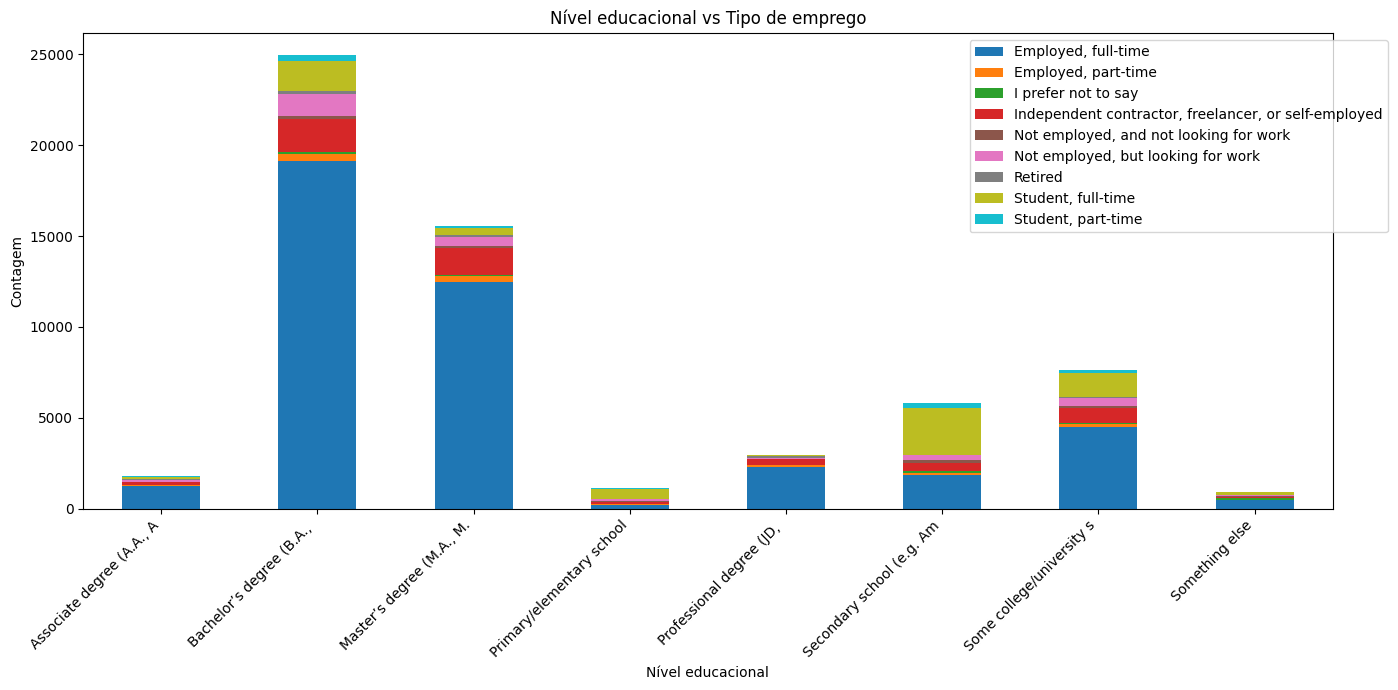

In [13]:
df['EdLevel_Short'] = df['EdLevel'].str.slice(0, 25)
df['Emp_Simple'] = df['Employment'].str.split(';').str[0]

crosstab_ed = pd.crosstab(df['EdLevel_Short'], df['Emp_Simple'])

crosstab_ed.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab10')
plt.title('Nível educacional vs Tipo de emprego')
plt.xlabel('Nível educacional')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [14]:
df.to_csv('survey_data_eda.csv', index=False)
print("Arquivo salvo!")
print(f"Shape final: {df.shape}")

Arquivo salvo!
Shape final: (65437, 117)


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
